In [3]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official')
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a_init, b = load_and_rotate(rotation='varimax')

a_df = pd.DataFrame(a_init, index=resmat.columns)
theta_df = pd.DataFrame(theta, index=resmat.index)

--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 19])
Original 'a' matrix shape: torch.Size([78712, 19])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 19)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 19)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.36679121 -1.29142072  0.02368664 ...  0.5948743   1.20452549
  -1.32143699]
 [ 0.8694796   0.65897874 -2.01923406 ... -0.49557078  1.18055759
  -1.37415132]
 [ 1.82481648 -1.4122685  -0.51204663 ...  0.78741921 -0.97111116
  -1.49879246]
 ...
 [-0.9912067  -0.93205986 -0.40201418 ...  0.99411487 -0.17602767
   1.24166521]
 [-0.71577314 -0.59205097 -0.52410342 ...  1.13348854 -0.10466067
   0.66230223]
 [ 0.18720646 -0.9709694   0.55470963 ...  0.3900838   1.68143397
  -0.28299898]]


Standardizing data...
Running GMM with BIC to find the optimal number of clusters...


Fitting GMMs:   0%|                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             | 0/40 [00:00<?, ?it/s]

Fitting GMMs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [21:25<00:00, 32.13s/it]



Best number of clusters by BIC: 12


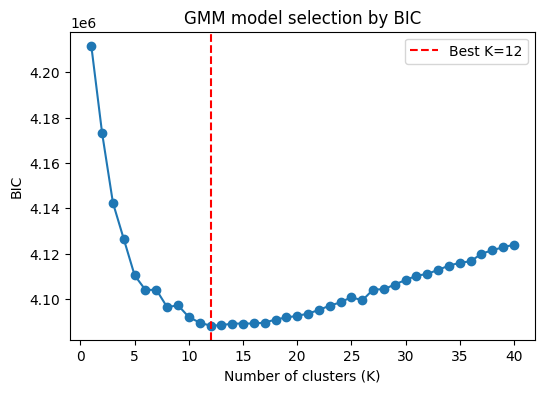

Saving results to CSV files...
Cluster assignments saved to item_clusters.csv
Cluster centroids saved to cluster_centroids.csv


In [ ]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm  # Import tqdm

# Assuming a_init and a_df are defined elsewhere
# Example placeholder data:
# a_init = np.random.rand(100, 10)
# a_df = pd.DataFrame(a_init, index=[f"item_{i}" for i in range(100)])


# ------------------- 1. Standardize -------------------
print("Standardizing data...")
X = StandardScaler().fit_transform(a_init)

# ------------------- 2. GMM with BIC -------------------
print("Running GMM with BIC to find the optimal number of clusters...")
Kmax = 40
bics = []
gmm_models = []
labels_list = []

# Wrap the range object with tqdm to create a progress bar
for K in tqdm(range(1, Kmax + 1), desc="Fitting GMMs"):
    gm = GaussianMixture(n_components=K, covariance_type='full', random_state=0)
    gm.fit(X)
    bics.append(gm.bic(X))
    gmm_models.append(gm)
    labels_list.append(gm.predict(X))

best_idx = int(np.argmin(bics))
best_K = best_idx + 1
best_model = gmm_models[best_idx]
best_labels = labels_list[best_idx]

print(f"\nBest number of clusters by BIC: {best_K}")

# ------------------- 3. Plot BIC curve -------------------
plt.figure(figsize=(6, 4))
plt.plot(range(1, Kmax + 1), bics, marker='o')
plt.axvline(best_K, color='r', linestyle='--', label=f'Best K={best_K}')
plt.xlabel("Number of clusters (K)")
plt.ylabel("BIC")
plt.legend()
plt.title("GMM model selection by BIC")
plt.show()

# ------------------- 4. Save results -------------------
print("Saving results to CSV files...")
# Add cluster labels to your items
clustered_df = pd.DataFrame({
    "item": a_df.index,
    "cluster": best_labels
})
clustered_df.to_csv("../result/item_clusters.csv", index=False)

# Compute cluster centroids (prototype skills)
centroids = pd.DataFrame(
    best_model.means_,
    columns=[f"dim_{i}" for i in range(a_init.shape[1])]
)
centroids["cluster"] = np.arange(best_K)
centroids.to_csv("../result/cluster_centroids.csv", index=False)
import pickle

with open("../result/bic_results.pkl", "wb") as f:
    pickle.dump({"bics": bics, "best_K": best_K}, f)

print("Cluster assignments saved to item_clusters.csv")
print("Cluster centroids saved to cluster_centroids.csv")

# Reload for plotting

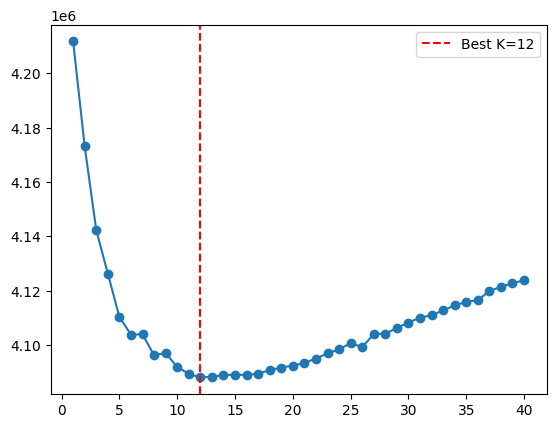

In [13]:
import pickle

with open("../result/bic_results.pkl", "rb") as f:
    bic_results = pickle.load(f)

plt.plot(range(1, len(bic_results["bics"])+1), bic_results["bics"], marker='o')
plt.axvline(best_K, color='r', linestyle='--', label=f'Best K={bic_results["best_K"]}')
plt.legend()
